# TianoCore Survey EDA
## Section 1: Demographics

---

TianoCore Survey — EDA Section 1: Demographics (Q67–Q70)
=========================================================
Questions:
  Q67 — Sex / Gender
  Q68 — Age Group
  Q69 — Country of Residence
  Q70 — Highest Academic Degree
Output: figures saved to OUT_DIR
Run in Colab after mounting Drive.

### Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Step 2 — Install dependencies (if needed)

In [2]:
!pip install matplotlib pandas -q

### Step 3 — Run analysis


Q67 — Sex/Gender (n=7/13):
  Male: 5 (71%)
  Prefer not to say: 2 (29%)


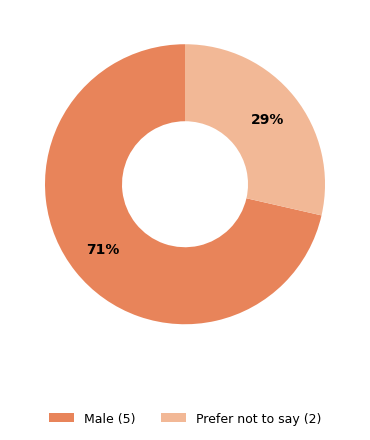

Saved: fig_01_sex_gender.png

Q68 — Age Group (n=7/13):
  25-34: 1 (14%)
  35-44: 2 (29%)
  55-64: 2 (29%)
  65+: 2 (29%)


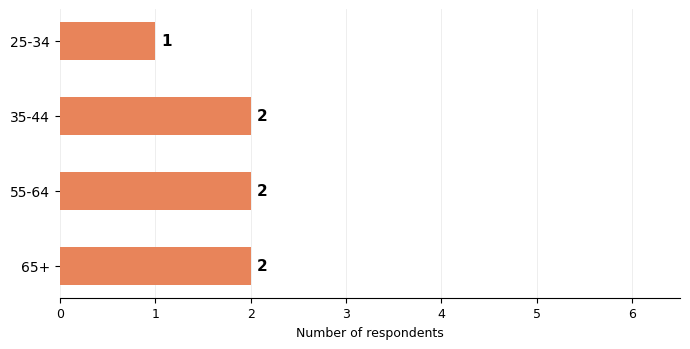

Saved: fig_02_age_group.png

Q69 — Country (n=7/13):
  United States: 5 (71%)
  Europe: 1 (14%)
  America other than the U.S./Canada: 1 (14%)


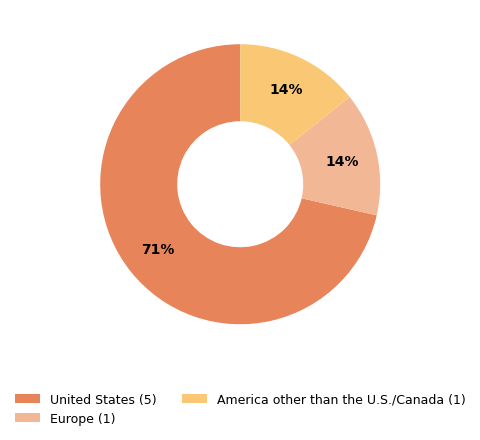

Saved: fig_03_country.png

Q70 — Highest Degree (n=7/13):
  Doctoral degree: 1 (14%)
  Bachelor’s degree: 3 (43%)
  Master’s degree: 3 (43%)


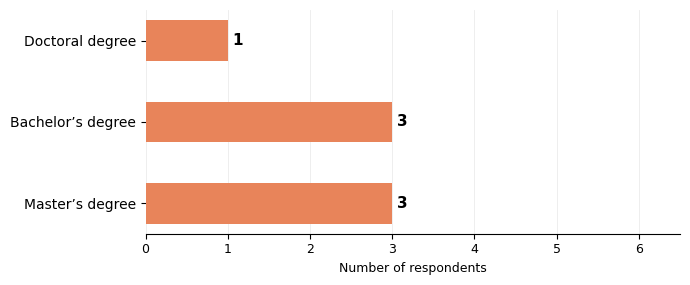

Saved: fig_04_degree.png

✓ Section 1 (Demographics) complete.


In [7]:
import os, pandas as pd, matplotlib.pyplot as plt
from collections import Counter, OrderedDict

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/TS-Survey/tianocore-survey_cleaned.csv"
OUT_DIR  = "/content/drive/MyDrive/TS-Survey/figures"
os.makedirs(OUT_DIR, exist_ok=True)
C_MAIN   = "#E8845A"   # soft terracotta (large slice)
C_SECOND = "#B4B2A9"   # gray (prefer not to say / other)
PIE_PALETTE = ["#E8845A", "#F2B896", "#FAC775", "#F0997B", "#97C459", "#B4B2A9", "#FFD7EE"]

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.grid": True, "axes.grid.axis": "x",
    "grid.color": "#ebebeb", "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "xtick.labelsize": 9, "ytick.labelsize": 10,
})

# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH, header=0, skiprows=[1, 2])
N  = len(df)

# ── HELPERS ───────────────────────────────────────────────────────────────────
def counts(col):
    return Counter(df[col].dropna().tolist())

def wrap(label, width=32):
    words = label.split(); lines = []; cur = ""
    for w in words:
        if cur and len(cur)+1+len(w) > width: lines.append(cur); cur = w
        else: cur = (cur+" "+w).strip()
    if cur: lines.append(cur)
    return "\n".join(lines)

def pick(label):
    lo = label.lower()
    return C_SECOND if any(k in lo for k in ("prefer not","other","specify")) else C_MAIN

def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show(); plt.close(fig)
    print(f"Saved: {name}")

def hbar(title, cnt, fname, max_x=None):
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    h = max(2.5, 0.65*len(items)+1.0)
    fig, ax = plt.subplots(figsize=(7, h))
    bars = ax.barh([wrap(l) for l in labels[::-1]], vals[::-1],
                   color=[pick(l) for l in labels[::-1]], height=0.5, zorder=3)
    ax.set_xlabel("Number of respondents", fontsize=9)
    ax.set_xlim(0, (max_x or max(vals))+1.5)
    for bar, v in zip(bars, vals[::-1]):
        if v > 0:
            ax.text(v+0.06, bar.get_y()+bar.get_height()/2,
                    str(v), va="center", fontsize=11, fontweight="bold")
    fig.tight_layout(); save(fig, fname)

def pie(title, cnt, fname):
    items  = list(cnt.items())
    labels = [i[0] for i in items]; vals = [i[1] for i in items]
    colours = [PIE_PALETTE[i % len(PIE_PALETTE)] for i in range(len(items))]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    wedges, _, autotexts = ax.pie(vals, colors=colours, autopct="%1.0f%%",
                                   startangle=90, wedgeprops=dict(width=0.55),
                                   pctdistance=0.75)
    for at in autotexts: at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("black")
    ax.legend(wedges, [f"{l} ({v})" for l, v in zip(labels, vals)],
              loc="lower center", bbox_to_anchor=(0.5,-0.22), fontsize=9, frameon=False, ncol=2)
    fig.tight_layout(); save(fig, fname)

# ── Q67: SEX / GENDER ─────────────────────────────────────────────────────────
g = counts("Q67")
print(f"\nQ67 — Sex/Gender (n={sum(g.values())}/{N}):")
for k,v in g.items(): print(f"  {k}: {v} ({100*v/sum(g.values()):.0f}%)")
pie("Q67 — Sex / Gender", g, "fig_01_sex_gender.png")

# ── Q68: AGE GROUP ────────────────────────────────────────────────────────────
age_order = ["Under 18","18-24","25-34","35-44","45-54","55-64","65+"]
age_raw   = counts("Q68")
age_cnt   = OrderedDict((k, age_raw[k]) for k in age_order if k in age_raw)
for k,v in age_raw.items():
    if k not in age_cnt: age_cnt[k] = v
print(f"\nQ68 — Age Group (n={sum(age_cnt.values())}/{N}):")
for k,v in age_cnt.items(): print(f"  {k}: {v} ({100*v/sum(age_cnt.values()):.0f}%)")
hbar("Q68 — Age Group", age_cnt, "fig_02_age_group.png", max_x=5)

# ── Q69: COUNTRY OF RESIDENCE ─────────────────────────────────────────────────
co = counts("Q69")
print(f"\nQ69 — Country (n={sum(co.values())}/{N}):")
for k,v in co.items(): print(f"  {k}: {v} ({100*v/sum(co.values()):.0f}%)")
pie("Q69 — Country of Residence", co, "fig_03_country.png")

# ── Q70: HIGHEST DEGREE ───────────────────────────────────────────────────────
deg_order = ["High school diploma or equivalent","Some college / Associate degree",
             "Bachelor's degree","Master's degree","Doctoral degree",
             "Professional degree (e.g., MD, JD)","Other"]
deg_raw   = counts("Q70")
deg_cnt   = OrderedDict((k, deg_raw[k]) for k in deg_order if k in deg_raw)
for k,v in deg_raw.items():
    if k not in deg_cnt: deg_cnt[k] = v
print(f"\nQ70 — Highest Degree (n={sum(deg_cnt.values())}/{N}):")
for k,v in deg_cnt.items(): print(f"  {k}: {v} ({100*v/sum(deg_cnt.values()):.0f}%)")
hbar("Q70 — Highest Degree", deg_cnt, "fig_04_degree.png", max_x=5)

print("\n✓ Section 1 (Demographics) complete.")